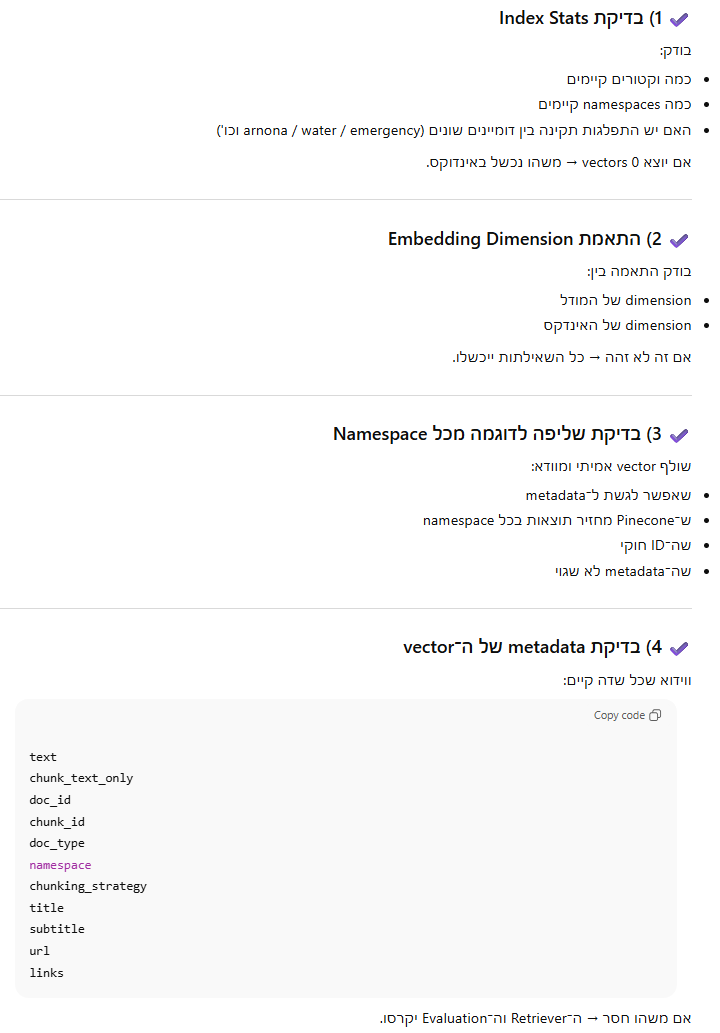

In [ ]:
"""
verify_index.py
----------------
Runs post-indexing validation on the Haifa municipality Pinecone index.

Checks:
1. Index exists and matches embedding dimension
2. Namespace list exists and is logical
3. Sample vectors load correctly from each namespace
4. Metadata fields are present and non-empty
5. No corrupted or missing data in indexed vectors

Usage:
    python verify_index.py \
        --api_keys_path api_keys.json \
        --index_name haifa-municipality-rag
"""

import argparse
from pinecone import Pinecone
from utils import (
    DEFAULT_API_KEYS_PATH,
    DEFAULT_INDEX_NAME,
    load_pinecone_api_key,
    EmbeddingModel,
    DEFAULT_EMBEDDING_MODEL,
)
import json

EXPECTED_FIELDS = [
    "text",
    "chunk_text_only",
    "doc_id",
    "chunk_id",
    "doc_type",
    "namespace",
    "chunking_strategy",
    "title",
    "subtitle",
    "url",
    "links",
]


def check_index_status(index):
    print("\n[1] Checking index status...")
    stats = index.describe_index_stats()
    print(json.dumps(stats, indent=2, ensure_ascii=False))

    total_vectors = stats.get("total_vector_count", 0)
    namespaces = list(stats.get("namespaces", {}).keys())

    print(f"\n[OK] Total vectors indexed: {total_vectors:,}")
    print(f"[OK] Namespaces found: {namespaces}")

    if total_vectors == 0:
        raise RuntimeError("Index contains 0 vectors. Indexing likely failed.")

    return namespaces


def check_embedding_dimension(embed_model, index):
    print("\n[2] Checking embedding dimension consistency...")

    expected_dim = embed_model.dimension
    info = index.describe()

    actual_dim = info.get("dimension", None)

    print(f"Model dimension: {expected_dim}")
    print(f"Index  dimension: {actual_dim}")

    if actual_dim != expected_dim:
        raise RuntimeError("Dimension mismatch! Index and model vectors incompatible.")

    print("[OK] Dimension match.\n")


def fetch_sample_vector(index, namespace):
    print(f"\n[3] Fetching sample vector from namespace '{namespace}' ...")

    # Query dummy vector (irrelevant vector, Pinecone returns closest)
    dummy = [0.0] * index.describe().get("dimension")

    result = index.query(
        vector=dummy,
        top_k=1,
        namespace=namespace,
        include_metadata=True
    )

    if not result.matches:
        raise RuntimeError(f"No vectors returned from namespace '{namespace}'")

    match = result.matches[0]
    metadata = match.get("metadata", {})

    print(f"[OK] Found vector ID: {match['id']}")
    print("[OK] Metadata fields present:")
    print(json.dumps(metadata, indent=2, ensure_ascii=False))

    return metadata


def check_metadata_fields(metadata):
    print("\n[4] Validating metadata fields...")

    missing = [f for f in EXPECTED_FIELDS if f not in metadata]

    if missing:
        raise RuntimeError(f"Metadata missing fields: {missing}")

    # Check non-empty
    for f in EXPECTED_FIELDS:
        if metadata[f] in [None, "", []]:
            print(f"[WARN] Metadata field '{f}' is empty")

    print("[OK] Metadata contains all required fields.\n")


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--api_keys_path", default=DEFAULT_API_KEYS_PATH)
    parser.add_argument("--index_name", default=DEFAULT_INDEX_NAME)
    parser.add_argument("--embedding_model", default=DEFAULT_EMBEDDING_MODEL)
    args = parser.parse_args()

    print("       Haifa RAG Index Verification")

    # Load Pinecone
    api_key = load_pinecone_api_key(args.api_keys_path)
    pc = Pinecone(api_key=api_key)
    index = pc.Index(args.index_name)

    # Load embedding model for dimension validation
    embed_model = EmbeddingModel(args.embedding_model)

    # Step 1: Index status
    namespaces = check_index_status(index)

    # Step 2: Dimension check
    check_embedding_dimension(embed_model, index)

    # Step 3–4: Metadata checks per namespace
    for ns in namespaces:
        print(f"Checking namespace: {ns}")

        metadata = fetch_sample_vector(index, ns)
        check_metadata_fields(metadata)

    print("[SUCCESS] Index is valid, consistent, and ready for Retriever!")


if __name__ == "__main__":
    main()
